In [4]:
import pandas as pd
import numpy as np
data = {
'Hoc sinh': ['HS1', 'HS2','HS3','HS4','HS5'],
'Toan': [80 , 70 , 90 , 60 , 75] ,
'Ly': [85 , 75 , 95 , 65 , 70] ,
'Hoa': [90 , 80 , 85 , 70 , 75]
}
df = pd.DataFrame(data)
df

,Hoc sinh,Toan,Ly,Hoa
0,HS1,80,85,90
1,HS2,70,75,80
2,HS3,90,95,85
3,HS4,60,65,70
4,HS5,75,70,75


In [7]:
mean_scores = df[['Toan', 'Ly', 'Hoa']].mean()
std_scores = df[['Toan', 'Ly', 'Hoa']].std(ddof = 0)
mean_scores, std_scores

(Toan    75.0
 Ly      78.0
 Hoa     80.0
 dtype: float64,
 Toan    10.000000
 Ly      10.770330
 Hoa      7.071068
 dtype: float64)

In [9]:
standardlize_df = df.copy()
standardlize_df[['Toan', 'Ly', 'Hoa']] = (df[['Toan', 'Ly', 'Hoa']] - mean_scores)/std_scores
standardlize_df

,Hoc sinh,Toan,Ly,Hoa
0,HS1,0.5,0.649934,1.414214
1,HS2,-0.5,-0.278543,0.000000
2,HS3,1.5,1.578410,0.707107
3,HS4,-1.5,-1.207020,-1.414214
4,HS5,0.0,-0.742781,-0.707107


<Axes: >

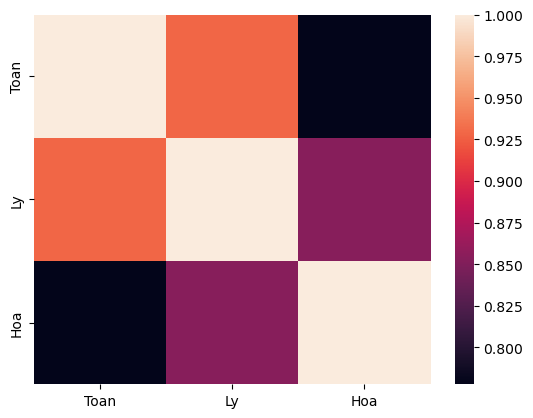

In [21]:
import seaborn as sns
cov_matrix = standardlize_df[['Toan', 'Ly', 'Hoa']].cov(ddof = 0)
cov_matrix
sns.heatmap(cov_matrix)

In [24]:
eig_val, eig_vec = np.linalg.eig(cov_matrix)
print("Eigen values :\n", eig_val)
print("Eigen vectors :\n", eig_vec)

Eigen values :
 [2.70800231 0.0590315  0.23296619]
Eigen vectors :
 [[-0.57779799 -0.58368886 -0.57048821]
 [-0.59386823  0.78014286 -0.19671717]
 [-0.55988392 -0.22513204  0.79739924]]


In [27]:
selec_eig_vec = eig_vec[:, [0, 2]]
reduced_data = standardlize_df[['Toan', 'Ly', 'Hoa']].dot(selec_eig_vec)
reduced_data.columns = ['PC1', 'PC3']
print(f"{selec_eig_vec}\n, {standardlize_df}")
print(" Reduced data :\n", reduced_data)

[[-0.57779799 -0.57048821]
 [-0.59386823 -0.19671717]
 [-0.55988392  0.79739924]]
,   Hoc sinh  Toan        Ly       Hoa
0      HS1   0.5  0.649934  1.414214
1      HS2  -0.5 -0.278543  0.000000
2      HS3   1.5  1.578410  0.707107
3      HS4  -1.5 -1.207020 -1.414214
4      HS5   0.0 -0.742781 -0.707107
 Reduced data :
         PC1       PC3
0 -1.466669  0.714596
1  0.454317  0.340038
2 -2.199962 -0.602386
3  2.375303 -0.034519
4  0.837012 -0.417729


In [29]:
df = pd.read_csv('diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [66]:
mean_scores = df.drop('Outcome', axis=1).mean()
std_scores = df.drop('Outcome', axis=1).std(ddof=0)
mean_scores, std_scores

(Pregnancies                   3.845052
 Glucose                     120.894531
 BloodPressure                69.105469
 SkinThickness                20.536458
 Insulin                      79.799479
 BMI                          31.992578
 DiabetesPedigreeFunction      0.471876
 Age                          33.240885
 dtype: float64,
 Pregnancies                   3.367384
 Glucose                      31.951796
 BloodPressure                19.343202
 SkinThickness                15.941829
 Insulin                     115.168949
 BMI                           7.879026
 DiabetesPedigreeFunction      0.331113
 Age                          11.752573
 dtype: float64)

In [68]:
standardlize_df = (df.drop('Outcome', axis=1) - mean_scores) / std_scores
standardlize_df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,0.639947,0.848324,0.149641,0.907270,-0.692891,0.204013,0.468492,1.425995
1,-0.844885,-1.123396,-0.160546,0.530902,-0.692891,-0.684422,-0.365061,-0.190672
2,1.233880,1.943724,-0.263941,-1.288212,-0.692891,-1.103255,0.604397,-0.105584
3,-0.844885,-0.998208,-0.160546,0.154533,0.123302,-0.494043,-0.920763,-1.041549
4,-1.141852,0.504055,-1.504687,0.907270,0.765836,1.409746,5.484909,-0.020496
...,...,...,...,...,...,...,...,...
763,1.827813,-0.622642,0.356432,1.722735,0.870031,0.115169,-0.908682,2.532136
764,-0.547919,0.034598,0.046245,0.405445,-0.692891,0.610154,-0.398282,-0.531023
765,0.342981,0.003301,0.149641,0.154533,0.279594,-0.735190,-0.685193,-0.275760
766,-0.844885,0.159787,-0.470732,-1.288212,-0.692891,-0.240205,-0.371101,1.170732


In [73]:
cov_matrix = standardlize_df.cov(ddof=0)
cov_matrix
# sns.heatmap(cov_matrix)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Pregnancies,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341
Glucose,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514
BloodPressure,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528
SkinThickness,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970
Insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163
BMI,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242
DiabetesPedigreeFunction,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561
Age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000


In [71]:
eig_val, eig_vec = np.linalg.eig(cov_matrix)
print("Eigen values :\n", eig_val)
print("Eigen vectors :\n", eig_vec)

Eigen values :
 [2.09437995 1.73121014 0.41981618 0.40446205 0.68262839 0.76234439
 0.87552904 1.02962987]
Eigen vectors :
 [[-0.1284321  -0.59378583 -0.58879003  0.11784098 -0.19359817  0.47560573
  -0.08069115  0.01308692]
 [-0.39308257 -0.17402908 -0.06015291  0.45035526 -0.09416176 -0.46632804
   0.40432871 -0.46792282]
 [-0.36000261 -0.18389207 -0.19211793 -0.01129554  0.6341159  -0.32795306
  -0.05598649  0.53549442]
 [-0.43982428  0.33196534  0.28221253  0.5662838  -0.00958944  0.48786206
  -0.03797608  0.2376738 ]
 [-0.43502617  0.25078106 -0.13200992 -0.54862138  0.27065061  0.34693481
   0.34994376 -0.33670893]
 [-0.45194134  0.1009598  -0.03536644 -0.34151764 -0.68537218 -0.25320376
  -0.05364595  0.36186463]
 [-0.27061144  0.122069   -0.08609107 -0.00825873  0.08578409 -0.11981049
  -0.8336801  -0.43318905]
 [-0.19802707 -0.62058853  0.71208542 -0.21166198  0.03335717  0.10928996
  -0.0712006  -0.07524755]]


In [72]:
selec_eig_vec = eig_vec[:, [0, 1]]
reduced_data = standardlize_df.dot(selec_eig_vec)
reduced_data.columns = ['PC1', 'PC2']
print(f"{selec_eig_vec}\n, {standardlize_df}")
print(" Reduced data :\n", reduced_data)

[[-0.1284321  -0.59378583]
 [-0.39308257 -0.17402908]
 [-0.36000261 -0.18389207]
 [-0.43982428  0.33196534]
 [-0.43502617  0.25078106]
 [-0.45194134  0.1009598 ]
 [-0.27061144  0.122069  ]
 [-0.19802707 -0.62058853]]
,      Pregnancies   Glucose  BloodPressure  SkinThickness   Insulin       BMI  \
0       0.639947  0.848324       0.149641       0.907270 -0.692891  0.204013   
1      -0.844885 -1.123396      -0.160546       0.530902 -0.692891 -0.684422   
2       1.233880  1.943724      -0.263941      -1.288212 -0.692891 -1.103255   
3      -0.844885 -0.998208      -0.160546       0.154533  0.123302 -0.494043   
4      -1.141852  0.504055      -1.504687       0.907270  0.765836  1.409746   
..           ...       ...            ...            ...       ...       ...   
763     1.827813 -0.622642       0.356432       1.722735  0.870031  0.115169   
764    -0.547919  0.034598       0.046245       0.405445 -0.692891  0.610154   
765     0.342981  0.003301       0.149641       0.154533  0.2

In [61]:
from sklearn.cluster import KMeans
import pandas as pd
new_data = pd.read_csv('diabetes.csv')
kmeans = KMeans(n_clusters = 2, random_state = 0).fit(new_data)
print("Cluster labels: ", kmeans.labels_)
print("Cluster centers: ", kmeans.cluster_centers_)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


Cluster labels:  [0 0 0 0 1 0 0 0 1 0 0 0 0 1 1 0 1 0 0 0 1 0 0 0 1 0 0 0 0 0 0 1 0 0 0 1 0
 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 1 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0
 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 1 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0
 0 0 1 0 1 1 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 1 0 0 1 0 0 0 0 0 1 0 0 0 1 0 0 0 0 1 0 1 0 0 0 0 0 0 0 1 1 0 0 0 0 1 0
 0 1 0 0 0 0 1 0 0 1 0 0 0 0 1 0 0 0 0 0 0 1 1 0 0 1 1 0 0 0 0 0 1 0 0 0 1
 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 1 1 0 0 0 0 1 1 0 0
 1 1 1 0 0 0 0 0 0 0 0 1 1 1 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 1 1 0 0 0 0 0 0
 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 1 0 0 0 1 0 0 0 0 0
 1 0 0 0 1 1 0 0 0 0 0 0 1 0 0 0 0 0 1 0 1 0 1 0 0 1 0 0 0 0 0 0 0 0 0 1 0
 0 0 1 0 1 1 0 1 1 0 0 0 0 1 0 0 0 1 1 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 1
 0 0 0 0

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


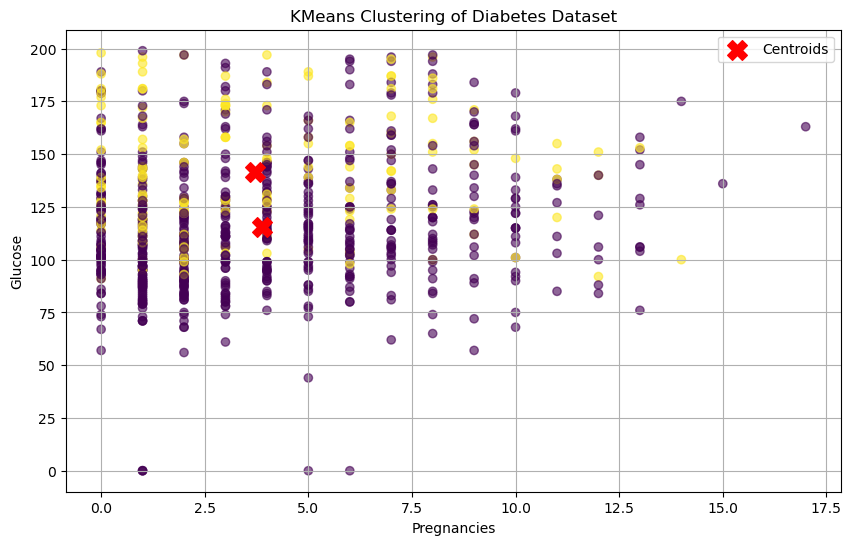

In [62]:
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Đọc dữ liệu
new_data = pd.read_csv('diabetes.csv')

kmeans = KMeans(n_clusters=2, random_state=0).fit(new_data)

new_data['Cluster'] = kmeans.labels_

x_col = new_data.columns[0]
y_col = new_data.columns[1]

plt.figure(figsize=(10, 6))
plt.scatter(new_data[x_col], new_data[y_col], c=new_data['Cluster'], cmap='viridis', alpha=0.6)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], c='red', marker='X', s=200, label='Centroids')
plt.xlabel(x_col)
plt.ylabel(y_col)
plt.title('KMeans Clustering of Diabetes Dataset')
plt.legend()
plt.grid(True)
plt.show()